# Cross-DEX Arbitrage Analysis

This notebook analyzes the historical Uniswap V3 vs SushiSwap V2 arbitrage backtest.

**Research question**

> Do temporary price discrepancies between Uniswap V3 and SushiSwap create profitable cross-DEX arbitrage opportunities after transaction costs?

The backtest already includes same-block spot prices, executable two-leg swap simulation, DEX fees and AMM price impact, historical Ethereum base fee, an assumed 300,000 gas units, and an assumed 1.0 gwei priority fee.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("../data/processed/arbitrage_multisize_500blocks_with_gas.csv")
FIGURE_DIR = Path("../results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print(f"Rows: {len(df):,}")
print(f"Distinct blocks: {df['block'].nunique():,}")
print(f"Trade sizes: {sorted(df['trade_size_usdc'].unique())}")

df.head()


Matplotlib is building the font cache; this may take a moment.


Rows: 2,500
Distinct blocks: 500
Trade sizes: [np.float64(100.0), np.float64(500.0), np.float64(1000.0), np.float64(5000.0), np.float64(10000.0)]


,block,timestamp,trade_size_usdc,uniswap_price,sushiswap_price,signed_spread,absolute_spread,relative_spread_pct,spot_buy_dex,spot_sell_dex,...,gas_cost_eth,gas_cost_usdc,route_a_net_pnl,route_a_net_return_pct,route_b_net_pnl,route_b_net_return_pct,best_route_after_gas,best_net_pnl_usdc,best_net_return_pct,profitable_after_gas
0,26015285,2026-09-20 00:57:59+00:00,100.0,2627.640658,2628.195751,0.555093,0.555093,0.021125,Uniswap V3,SushiSwap V2,...,0.000316,0.830374,-1.271034,-1.271034,-1.228945,-1.228945,Uniswap V3 -> SushiSwap V2,-1.228945,-1.228945,False
1,26015285,2026-09-20 00:57:59+00:00,500.0,2627.640658,2628.195751,0.555093,0.555093,0.021125,Uniswap V3,SushiSwap V2,...,0.000316,0.830374,-4.424049,-0.884810,-4.213797,-0.842759,Uniswap V3 -> SushiSwap V2,-4.213797,-0.842759,False
2,26015285,2026-09-20 00:57:59+00:00,1000.0,2627.640658,2628.195751,0.555093,0.555093,0.021125,Uniswap V3,SushiSwap V2,...,0.000316,0.830374,-11.471901,-1.147190,-11.051876,-1.105188,Uniswap V3 -> SushiSwap V2,-11.051876,-1.105188,False
3,26015285,2026-09-20 00:57:59+00:00,5000.0,2627.640658,2628.195751,0.555093,0.555093,0.021125,Uniswap V3,SushiSwap V2,...,0.000316,0.830374,-187.995881,-3.759918,-185.915510,-3.718310,Uniswap V3 -> SushiSwap V2,-185.915510,-3.718310,False
4,26015285,2026-09-20 00:57:59+00:00,10000.0,2627.640658,2628.195751,0.555093,0.555093,0.021125,Uniswap V3,SushiSwap V2,...,0.000316,0.830374,-690.319217,-6.903192,-686.210240,-6.862102,Uniswap V3 -> SushiSwap V2,-686.210240,-6.862102,False


## 1. Summary statistics

Spot spread is a block-level variable, so it is calculated once per block for summary statistics rather than averaging the same spread five times across trade sizes.


In [2]:
block_df = (
    df.sort_values("block")
      .drop_duplicates(subset=["block"])
      .copy()
)

summary = pd.DataFrame({
    "Metric": [
        "Simulations",
        "Distinct blocks",
        "Average spot spread (%)",
        "Maximum spot spread (%)",
        "Profitable before gas",
        "Profitable after gas",
        "Average gas cost (USDC)",
        "Maximum before-gas PnL (USDC)",
        "Maximum after-gas net PnL (USDC)",
    ],
    "Value": [
        len(df),
        df["block"].nunique(),
        block_df["relative_spread_pct"].mean(),
        block_df["relative_spread_pct"].max(),
        int(df["profitable_before_gas"].sum()),
        int(df["profitable_after_gas"].sum()),
        block_df["gas_cost_usdc"].mean(),
        df["best_pnl_before_gas"].max(),
        df["best_net_pnl_usdc"].max(),
    ],
})

summary


,Metric,Value
0,Simulations,2500.000000
1,Distinct blocks,500.000000
2,Average spot spread (%),0.183168
3,Maximum spot spread (%),0.349652
4,Profitable before gas,0.000000
5,Profitable after gas,0.000000
6,Average gas cost (USDC),0.830797
7,Maximum before-gas PnL (USDC),-0.071679
8,Maximum after-gas net PnL (USDC),-0.904788


## 2. Spot spread over time

The fee-only break-even line ignores price impact and gas. With a 0.30% SushiSwap V2 fee and a 0.05% Uniswap V3 fee, the theoretical minimum round-trip spread is:

\[
\left(\frac{1}{0.997\times0.9995}-1\right)\times100
\]

Any real executable break-even spread should be higher because price impact and gas still need to be covered.


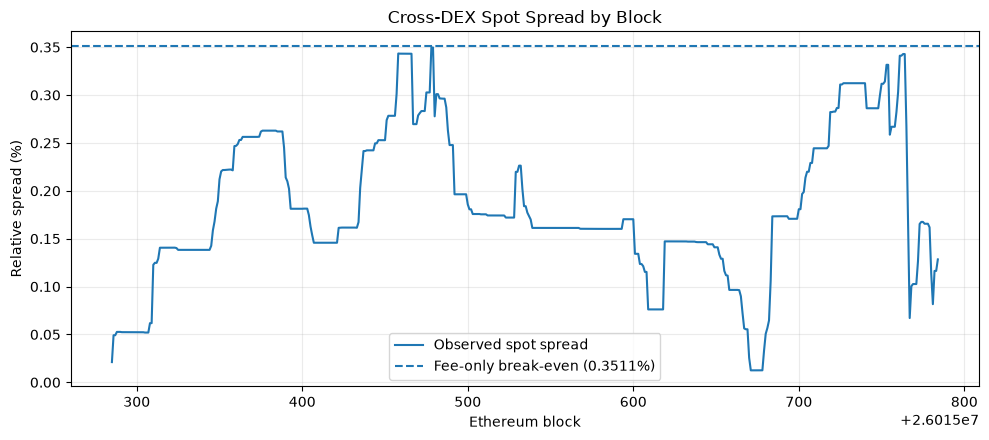

In [3]:
fee_only_break_even_pct = (
    1 / (0.997 * 0.9995) - 1
) * 100

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    block_df["block"],
    block_df["relative_spread_pct"],
    linewidth=1.5,
    label="Observed spot spread",
)

ax.axhline(
    fee_only_break_even_pct,
    linestyle="--",
    linewidth=1.5,
    label=f"Fee-only break-even ({fee_only_break_even_pct:.4f}%)",
)

ax.set_title("Cross-DEX Spot Spread by Block")
ax.set_xlabel("Ethereum block")
ax.set_ylabel("Relative spread (%)")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_spread_over_blocks.png", dpi=160)
plt.show()


## 3. PnL by trade size

This comparison shows the interaction between capital size and AMM execution costs.

- Small trades have lower price impact, but gas is large relative to capital.
- Large trades dilute the fixed gas cost, but price impact becomes much more severe.


In [4]:
size_summary = (
    df.groupby("trade_size_usdc")
      .agg(
          avg_pnl_before_gas=("best_pnl_before_gas", "mean"),
          avg_net_pnl=("best_net_pnl_usdc", "mean"),
          avg_net_return_pct=("best_net_return_pct", "mean"),
          max_pnl_before_gas=("best_pnl_before_gas", "max"),
          max_net_pnl=("best_net_pnl_usdc", "max"),
      )
      .reset_index()
)

size_summary


,trade_size_usdc,avg_pnl_before_gas,avg_net_pnl,avg_net_return_pct,max_pnl_before_gas,max_net_pnl
0,100.0,-0.237374,-1.068171,-1.068171,-0.071679,-0.904788
1,500.0,-2.582988,-3.413785,-0.682757,-1.758622,-2.595786
2,1000.0,-8.634370,-9.465167,-0.946517,-6.995817,-7.832981
3,5000.0,-177.672540,-178.503337,-3.570067,-169.869258,-170.706422
4,10000.0,-671.741259,-672.572056,-6.725721,-657.027021,-657.864185


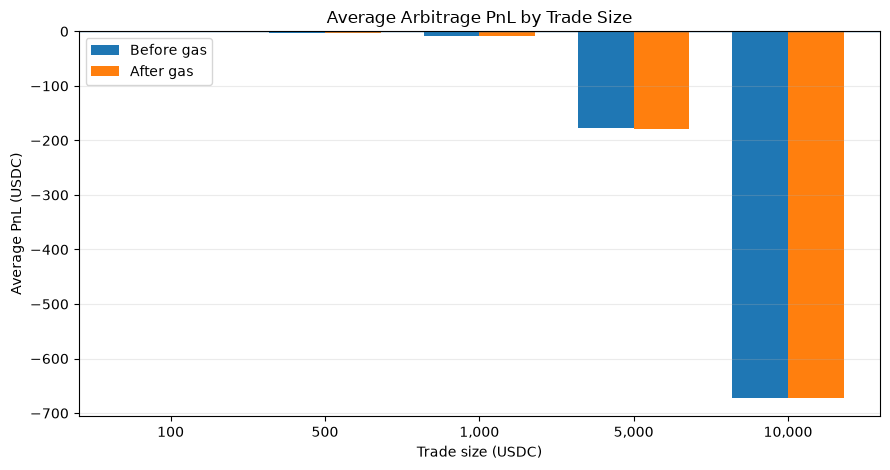

In [5]:
x = np.arange(len(size_summary))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.bar(
    x - width / 2,
    size_summary["avg_pnl_before_gas"],
    width,
    label="Before gas",
)

ax.bar(
    x + width / 2,
    size_summary["avg_net_pnl"],
    width,
    label="After gas",
)

ax.set_title("Average Arbitrage PnL by Trade Size")
ax.set_xlabel("Trade size (USDC)")
ax.set_ylabel("Average PnL (USDC)")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{v:,.0f}" for v in size_summary["trade_size_usdc"]]
)
ax.axhline(0, linewidth=1)
ax.legend()
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_pnl_by_trade_size.png", dpi=160)
plt.show()


## 4. Spread vs executable PnL

The 100 USDC series is used here because it has the lowest price impact and is the closest to the theoretical fee-only arbitrage boundary. This makes the relationship between market spread and executable profitability easiest to see.


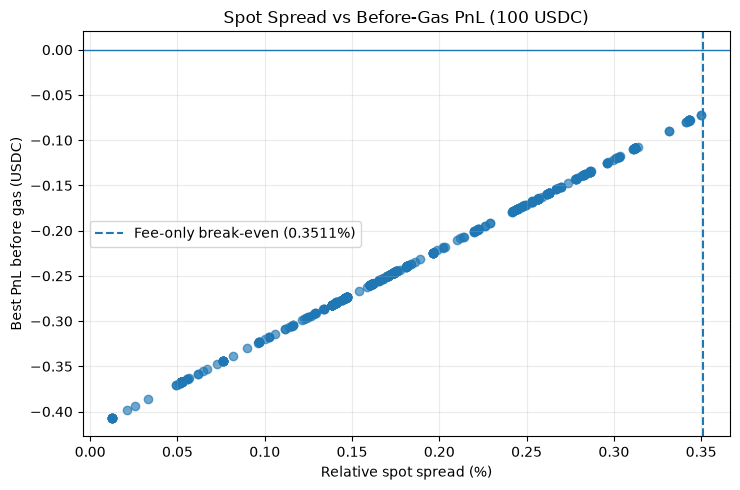

Correlation between spread and before-gas PnL: 1.0000


In [6]:
small_trade_df = df[
    df["trade_size_usdc"] == df["trade_size_usdc"].min()
].copy()

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.scatter(
    small_trade_df["relative_spread_pct"],
    small_trade_df["best_pnl_before_gas"],
    alpha=0.65,
)

ax.axhline(0, linewidth=1)
ax.axvline(
    fee_only_break_even_pct,
    linestyle="--",
    linewidth=1.5,
    label=f"Fee-only break-even ({fee_only_break_even_pct:.4f}%)",
)

ax.set_title(
    f"Spot Spread vs Before-Gas PnL "
    f"({small_trade_df['trade_size_usdc'].iloc[0]:.0f} USDC)"
)
ax.set_xlabel("Relative spot spread (%)")
ax.set_ylabel("Best PnL before gas (USDC)")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_spread_vs_pnl.png", dpi=160)
plt.show()

corr = small_trade_df[
    ["relative_spread_pct", "best_pnl_before_gas"]
].corr().iloc[0, 1]

print(f"Correlation between spread and before-gas PnL: {corr:.4f}")


## 5. Closest-to-profitable observations

The table below ranks observations by after-gas net PnL, so the first rows are the closest the sample came to a genuinely profitable cross-DEX arbitrage.


In [7]:
top10 = (
    df.sort_values(
        "best_net_pnl_usdc",
        ascending=False,
    )
    [[
        "block",
        "timestamp",
        "trade_size_usdc",
        "relative_spread_pct",
        "best_route_after_gas",
        "best_pnl_before_gas",
        "gas_cost_usdc",
        "best_net_pnl_usdc",
        "best_net_return_pct",
    ]]
    .head(10)
)

top10


,block,timestamp,trade_size_usdc,relative_spread_pct,best_route_after_gas,best_pnl_before_gas,gas_cost_usdc,best_net_pnl_usdc,best_net_return_pct
865,26015458,2026-09-20 01:32:47+00:00,100.0,0.343361,Uniswap V3 -> SushiSwap V2,-0.077914,0.826874,-0.904788,-0.904788
2395,26015764,2026-09-20 02:34:23+00:00,100.0,0.342791,Uniswap V3 -> SushiSwap V2,-0.078590,0.828830,-0.907420,-0.907420
2380,26015761,2026-09-20 02:33:47+00:00,100.0,0.341060,Uniswap V3 -> SushiSwap V2,-0.080312,0.827425,-0.907737,-0.907737
2390,26015763,2026-09-20 02:34:11+00:00,100.0,0.342834,Uniswap V3 -> SushiSwap V2,-0.078546,0.829524,-0.908070,-0.908070
900,26015465,2026-09-20 01:34:11+00:00,100.0,0.343113,Uniswap V3 -> SushiSwap V2,-0.078161,0.830025,-0.908186,-0.908186
965,26015478,2026-09-20 01:36:47+00:00,100.0,0.349652,Uniswap V3 -> SushiSwap V2,-0.071679,0.837164,-0.908843,-0.908843
970,26015479,2026-09-20 01:36:59+00:00,100.0,0.349652,Uniswap V3 -> SushiSwap V2,-0.071679,0.837489,-0.909168,-0.909168
870,26015459,2026-09-20 01:32:59+00:00,100.0,0.343201,Uniswap V3 -> SushiSwap V2,-0.078073,0.831183,-0.909256,-0.909256
885,26015462,2026-09-20 01:33:35+00:00,100.0,0.343201,Uniswap V3 -> SushiSwap V2,-0.078073,0.832497,-0.910570,-0.910570
875,26015460,2026-09-20 01:33:11+00:00,100.0,0.343201,Uniswap V3 -> SushiSwap V2,-0.078073,0.832572,-0.910645,-0.910645


## 6. Interpretation of the current 500-block sample

For the current run:

- Average spot spread was approximately **0.1832%**.
- Maximum spot spread was approximately **0.3497%**.
- The theoretical fee-only break-even spread is approximately **0.3511%**.
- There were **0 profitable simulations before gas** and **0 profitable simulations after gas**.
- The best before-gas result was about **-0.0717 USDC** on a 100 USDC trade.
- Average gas cost was about **0.831 USDC** under the 300,000 gas / 1.0 gwei priority-fee assumption.
- The best after-gas result was about **-0.9048 USDC**.

### Main finding

The two DEXs did exhibit temporary spot-price discrepancies, but in this sample the observed spreads were not large enough to overcome the complete execution-cost stack.

$$
\text{Net PnL}
=
\text{Cross-DEX spread gain}
-
\text{DEX fees}
-
\text{Price impact}
-
\text{Gas cost}
$$

For small trades, AMM price impact is limited but fixed gas cost is significant relative to capital. For large trades, gas becomes relatively less important, while AMM price impact dominates and sharply reduces returns.

Therefore, the current evidence supports a narrow conclusion:

> **Within this 500-block sample, observed Uniswap V3 / SushiSwap V2 price discrepancies did not produce profitable executable arbitrage after transaction costs.**

This does not establish that profitable opportunities never occur. A longer historical sample would be needed to estimate their frequency and identify more extreme dislocation periods.